In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
X = np.load(r"C:\Users\Vikihyaat Ahlawat\release_gene_analysis_data\data\p1\X.npy")
X=pd.DataFrame(X)
print(X.head())
print(X.shape)
X[0].max()

   0      1           2           3         4          5          6      \
0    0.0    0.0  133.855304  164.894216  0.000000  24.249149   3.879864   
1    0.0    0.0   60.255141   97.772493  3.410668   0.000000   1.136889   
2    0.0    0.0  129.614628  149.288277  0.000000  19.673649   0.000000   
3    0.0    0.0  100.392193  117.439923  0.000000  45.460615   0.000000   
4    0.0    0.0   78.890168  191.926828  0.000000  10.597187  12.952117   

   7          8           9      ...  45758  45759  45760  45761  45762  \
0    0.0  93.116733   64.017754  ...    0.0    0.0    0.0    0.0    0.0   
1    0.0  28.422236   36.380462  ...    0.0    0.0    0.0    0.0    0.0   
2    0.0  20.830922   79.851869  ...    0.0    0.0    0.0    0.0    0.0   
3    0.0   0.000000  161.006346  ...    0.0    0.0    0.0    0.0    0.0   
4    0.0  43.566212   25.904234  ...    0.0    0.0    0.0    0.0    0.0   

   45763  45764  45765  45766  45767  
0    0.0    0.0    0.0    0.0    0.0  
1    0.0    0.0    0

11.941397591320595

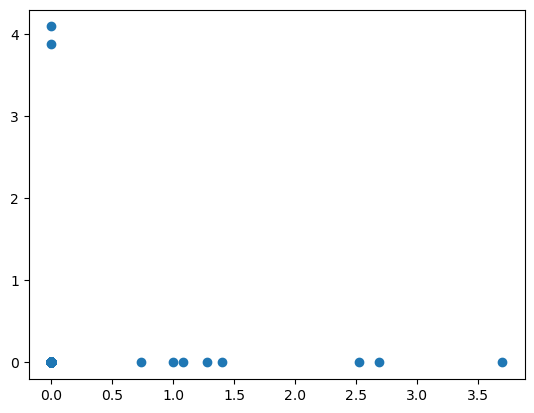

In [86]:
# Due to the presence of genes with extremely high magnitudes of expression in only a few cells, 
#it is common to apply a log-transform to the data, that is, to apply the transform

Log_X= np.log2(X+1)
plt.scatter(Log_X.loc[:,0],Log_X.loc[:,1])
plt.show()

In [87]:

Log_X.iloc[:,0].max()
Log_X.head()
Log_X.shape

(511, 45768)

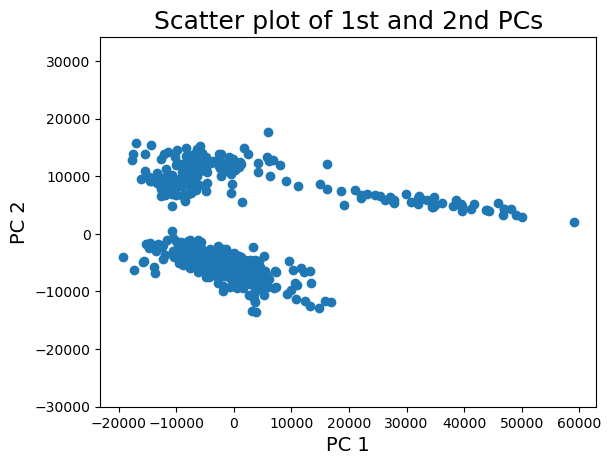

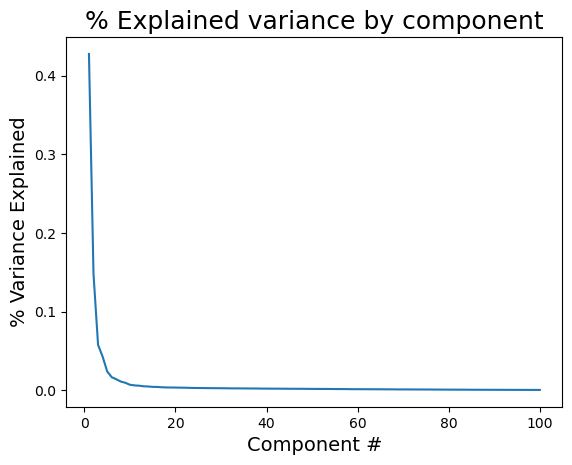

0.4277967098357276


35

In [88]:
# PCA
# PCA can produce an informative visualization where global structure and distances are preserved.
#We see two larger clusters and one smaller cluster; far-away clusters in the visualization are far-apart in the original space.
from sklearn.decomposition import PCA


pca = PCA() # Initialize with n_components parameter to only find the top eigenvectors
z = pca.fit_transform(X)


plt.scatter(z[:,0],z[:,1])
plt.title("Scatter plot of 1st and 2nd PCs",size=18)
plt.xlabel("PC 1",size=14)
plt.ylabel("PC 2",size=14)
plt.axis("equal")
plt.show()





#Deciding how many principal components to use

# scree/elbow

plt.plot(np.arange(1,101),pca.explained_variance_ratio_[0:100])
plt.title("% Explained variance by component",size=18)
plt.xlabel("Component #",size=14)
plt.ylabel("% Variance Explained",size=14)
plt.show()
print(pca.explained_variance_ratio_[0]) # Variation by 1st PC or its largest eigenvalue
np.sum(pca.explained_variance_ratio_[0:36])
#Or
np.where(np.cumsum(pca.explained_variance_ratio_) >=.85)[0][0]

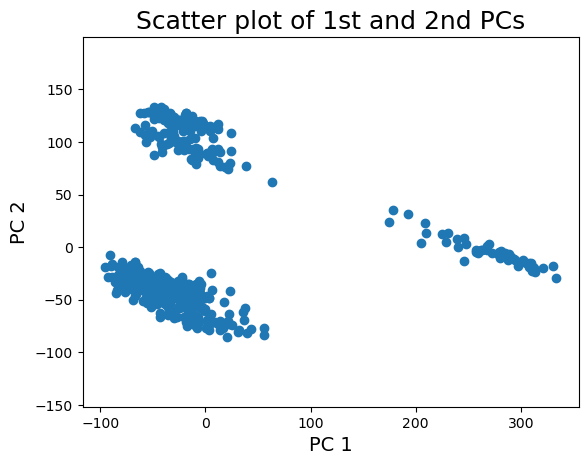

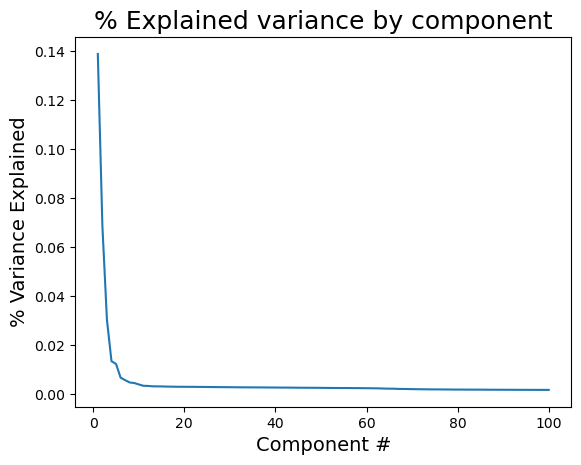

0.8513352867444813

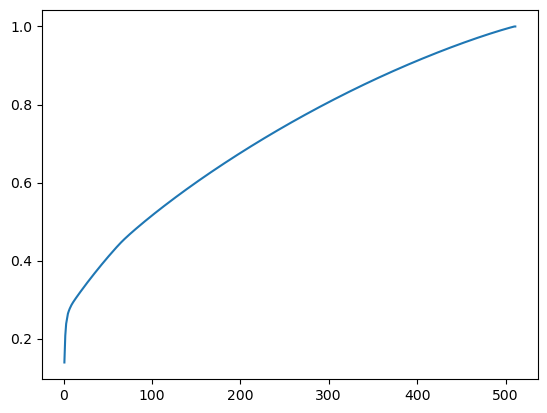

In [91]:
# Do it for log transformed data
Log_z = pca.fit_transform(Log_X)


plt.scatter(Log_z[:,0],Log_z[:,1])
plt.title("Scatter plot of 1st and 2nd PCs",size=18)
plt.xlabel("PC 1",size=14)
plt.ylabel("PC 2",size=14)
plt.axis("equal")
plt.show()





#Deciding how many principal components to use

# scree/elbow

plt.plot(np.arange(1,101),pca.explained_variance_ratio_[0:100])
plt.title("% Explained variance by component",size=18)
plt.xlabel("Component #",size=14)
plt.ylabel("% Variance Explained",size=14)
plt.show()
#To get a better idea of how the explained variance grow as more PCs are included, plot the cumulative explained variance versus number of PCs.

cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(np.arange(1,len(cumulative_explained_variance) + 1),cumulative_explained_variance) 
np.sum(pca.explained_variance_ratio_[0:340])

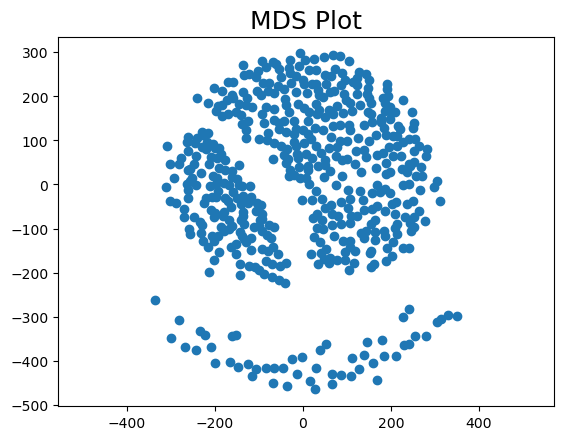

In [92]:
# wE work with log transformed data only 

# MDS
from sklearn.manifold import MDS


# MDS can be slow when n is large
mds = MDS(n_components=2,verbose=1,eps=1e-5)
mds.fit(Log_X)
plt.scatter(mds.embedding_[:,0],mds.embedding_[:,1])
plt.title("MDS Plot",size=18)
plt.axis("equal")
plt.show()

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 511 samples in 0.032s...
[t-SNE] Computed neighbors for 511 samples in 0.590s...
[t-SNE] Computed conditional probabilities for sample 511 / 511
[t-SNE] Mean sigma: 58.185914
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.452564
[t-SNE] KL divergence after 1000 iterations: 0.698477


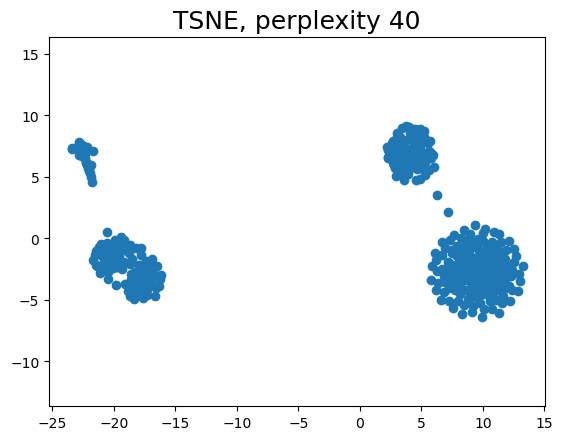

In [93]:
from sklearn.manifold import TSNE

#Distances in the T-SNE graph don't necessarily mean anything! For some datasets, T-SNE needs dimensionality reduction to reveal the clusters.
tsne = TSNE(n_components=2,verbose=1,perplexity=40)
z_tsne = tsne.fit_transform(Log_X)
plt.scatter(z_tsne[:,0],z_tsne[:,1])
plt.title("TSNE, perplexity 40",size=18)
plt.axis("equal")
plt.show()



[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 511 samples in 0.000s...
[t-SNE] Computed neighbors for 511 samples in 0.086s...
[t-SNE] Computed conditional probabilities for sample 511 / 511
[t-SNE] Mean sigma: 16.742845
[t-SNE] KL divergence after 250 iterations with early exaggeration: 66.829857
[t-SNE] KL divergence after 1000 iterations: 0.722678


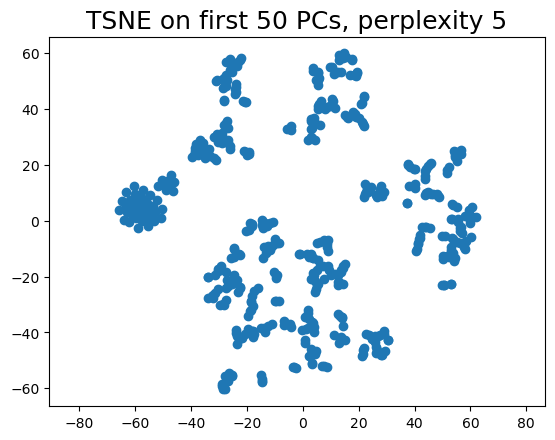

In [134]:
# tsne on first n PCs

tsne = TSNE(n_components=2,verbose=1,perplexity=5)
z_tsne = tsne.fit_transform(Log_z[:,0:50])
plt.scatter(z_tsne[:,0],z_tsne[:,1])
plt.title("TSNE on first 50 PCs, perplexity 5",size=18)
plt.axis("equal")
plt.show()

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 511 samples in 0.000s...
[t-SNE] Computed neighbors for 511 samples in 0.087s...
[t-SNE] Computed conditional probabilities for sample 511 / 511
[t-SNE] Mean sigma: 28.490462
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.332451
[t-SNE] KL divergence after 1000 iterations: 0.517374


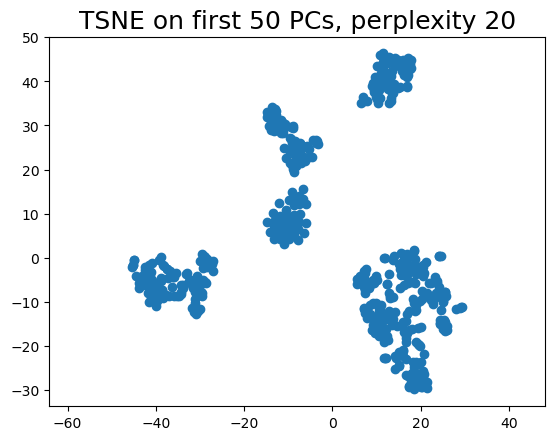

In [126]:
tsne = TSNE(n_components=2,verbose=1,perplexity=20)
z_tsne = tsne.fit_transform(Log_z[:,0:50])
plt.scatter(z_tsne[:,0],z_tsne[:,1])
plt.title("TSNE on first 50 PCs, perplexity 20",size=18)
plt.axis("equal")
plt.show()

[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 511 samples in 0.001s...
[t-SNE] Computed neighbors for 511 samples in 0.095s...
[t-SNE] Computed conditional probabilities for sample 511 / 511
[t-SNE] Mean sigma: 41.937018
[t-SNE] KL divergence after 250 iterations with early exaggeration: 47.346058
[t-SNE] KL divergence after 1000 iterations: 0.346923


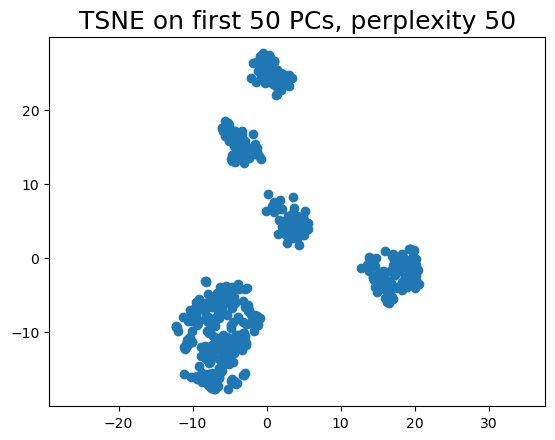

In [130]:
tsne = TSNE(n_components=2,verbose=1,perplexity=50)
z_tsne = tsne.fit_transform(Log_z[:,0:50])
plt.scatter(z_tsne[:,0],z_tsne[:,1])
plt.title("TSNE on first 50 PCs, perplexity 50",size=18)
plt.axis("equal")
plt.show()

[t-SNE] Computing 510 nearest neighbors...
[t-SNE] Indexed 511 samples in 0.000s...
[t-SNE] Computed neighbors for 511 samples in 0.110s...
[t-SNE] Computed conditional probabilities for sample 511 / 511
[t-SNE] Mean sigma: 84.332208
[t-SNE] KL divergence after 200 iterations with early exaggeration: 39.846958
[t-SNE] KL divergence after 700 iterations: 0.076491


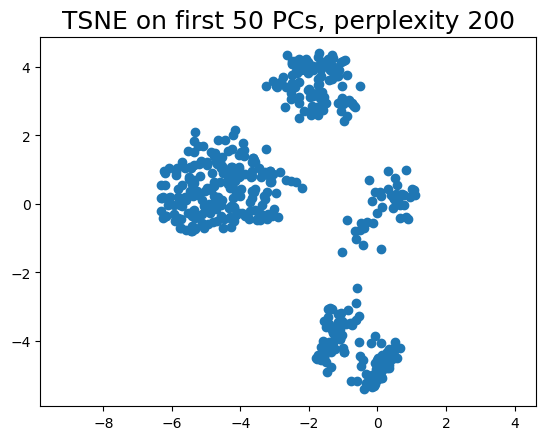

In [132]:
tsne = TSNE(n_components=2,verbose=1,perplexity=200)
z_tsne = tsne.fit_transform(Log_z[:,0:50])
plt.scatter(z_tsne[:,0],z_tsne[:,1])
plt.title("TSNE on first 50 PCs, perplexity 200",size=18)
plt.axis("equal")
plt.show()

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 511 samples in 0.003s...
[t-SNE] Computed neighbors for 511 samples in 0.094s...
[t-SNE] Computed conditional probabilities for sample 511 / 511
[t-SNE] Mean sigma: 75.982192
[t-SNE] KL divergence after 250 iterations with early exaggeration: 83.576248
[t-SNE] KL divergence after 1000 iterations: 0.964683


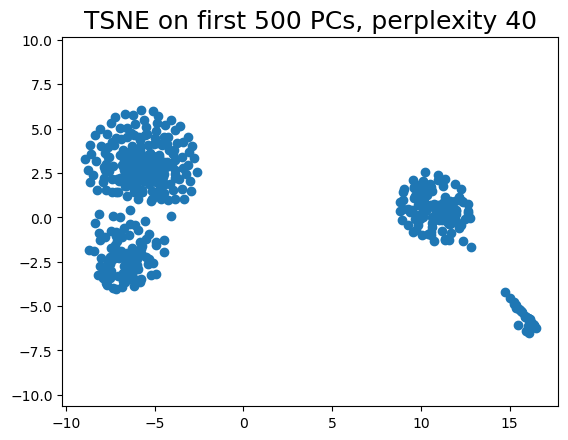

In [114]:
tsne = TSNE(n_components=2,verbose=1,perplexity=40)
z_tsne = tsne.fit_transform(Log_z[:,0:500])
plt.scatter(z_tsne[:,0],z_tsne[:,1])
plt.title("TSNE on first 500 PCs, perplexity 40",size=18)
plt.axis("equal")
plt.show()

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 511 samples in 0.003s...
[t-SNE] Computed neighbors for 511 samples in 0.099s...
[t-SNE] Computed conditional probabilities for sample 511 / 511
[t-SNE] Mean sigma: 58.185914
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.522987
[t-SNE] KL divergence after 1000 iterations: 0.698982


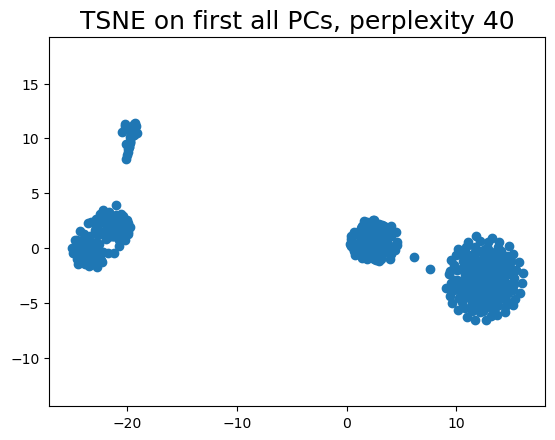

In [116]:
tsne = TSNE(n_components=2,verbose=1,perplexity=40)
z_tsne = tsne.fit_transform(Log_z)
plt.scatter(z_tsne[:,0],z_tsne[:,1])
plt.title("TSNE on first all PCs, perplexity 40",size=18)
plt.axis("equal")
plt.show()

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


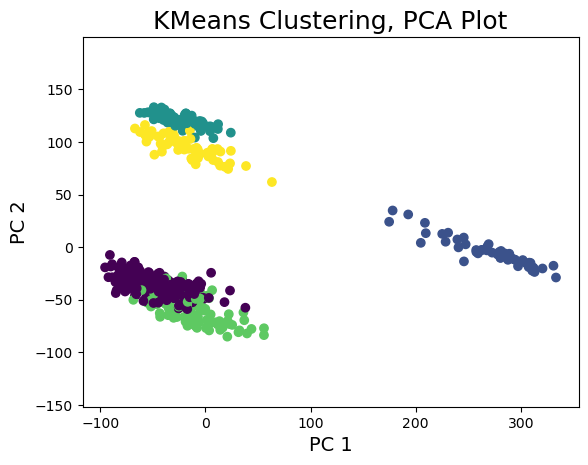

In [136]:
# k means clustering

from sklearn.cluster import KMeans

# Check number of initializations

kmeans = KMeans(n_clusters=5,n_init=100)
y = kmeans.fit_predict(Log_z)
plt.scatter(Log_z[:,0],Log_z[:,1],c=y)
plt.title("KMeans Clustering, PCA Plot",size=18)
plt.xlabel("PC 1",size=14)
plt.ylabel("PC 2",size=14)
plt.axis("equal")
plt.show()

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


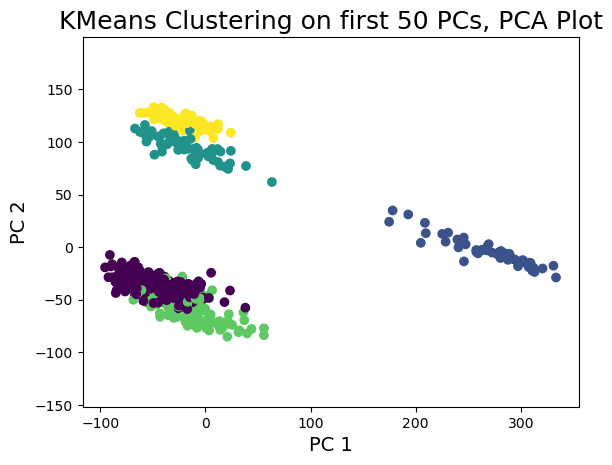

In [163]:
# k means clustering on first 50 PCs

from sklearn.cluster import KMeans

# Check number of initializations

kmeans = KMeans(n_clusters=5,n_init=100)
y = kmeans.fit_predict(Log_z[:,0:50])
plt.scatter(Log_z[:,0],Log_z[:,1],c=y)
plt.title("KMeans Clustering on first 50 PCs, PCA Plot",size=18)
plt.xlabel("PC 1",size=14)
plt.ylabel("PC 2",size=14)
plt.axis("equal")
plt.show()


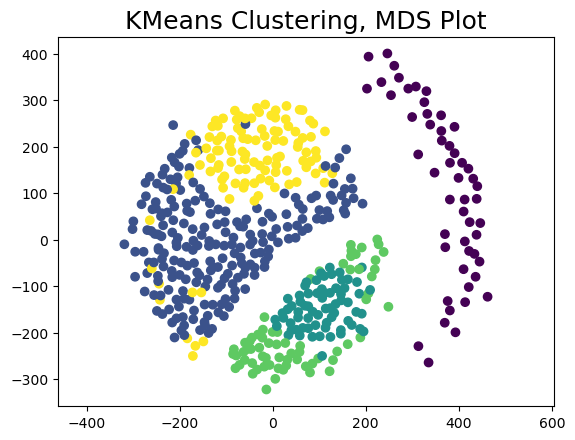

In [12]:

plt.scatter(mds.embedding_[:,0],mds.embedding_[:,1],c=y)
plt.title("KMeans Clustering, MDS Plot",size=18)
plt.axis("equal")
plt.show()

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 511 samples in 0.032s...
[t-SNE] Computed neighbors for 511 samples in 0.640s...
[t-SNE] Computed conditional probabilities for sample 511 / 511
[t-SNE] Mean sigma: 58.185914
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.452564
[t-SNE] KL divergence after 1000 iterations: 0.698477


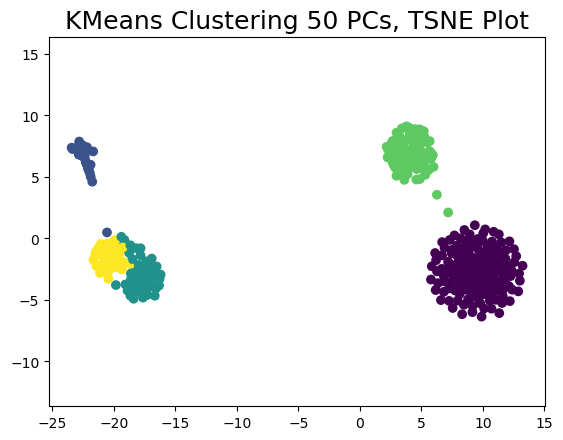

In [164]:
tsne = TSNE(n_components=2,verbose=1,perplexity=40)
z_tsne = tsne.fit_transform(Log_X)
plt.scatter(z_tsne[:,0],z_tsne[:,1],c=y)
plt.title("KMeans Clustering 50 PCs, TSNE Plot",size=18)
plt.axis("equal")
plt.show()

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

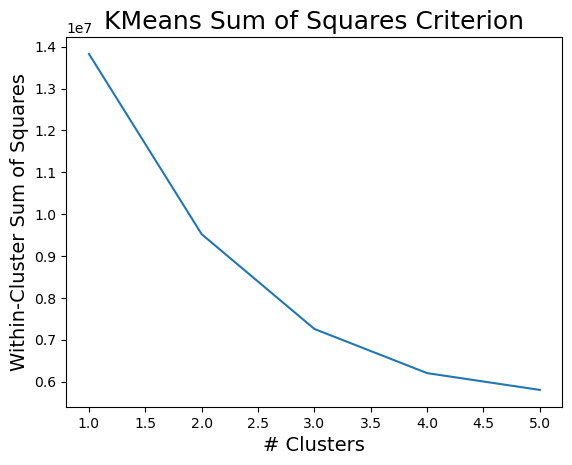

5801585.18091383


In [14]:
#  Diagnostics: Sum of squares criterion, Silhouette
#Sum of squares criterion is called "inertia" in sklearn. We can make an elbow plot:

all_kmeans = [KMeans(n_clusters=i+1,n_init=100) for i in range(8)]
# i-th kmeans fits i+1 clusters
for i in range(5):
    all_kmeans[i].fit(Log_z[:,0:50])

inertias = [all_kmeans[i].inertia_ for i in range(5)]
plt.plot(np.arange(1,6),inertias)
plt.title("KMeans Sum of Squares Criterion",size=18)
plt.xlabel("# Clusters",size=14)
plt.ylabel("Within-Cluster Sum of Squares",size=14)
plt.show()

print(inertias[4])



In [15]:
print(inertias[4])



5801585.18091383


breaking at iteration 111 with stress 6080.3108576076775
breaking at iteration 100 with stress 6342.479780834233
breaking at iteration 139 with stress 6080.304724023656
breaking at iteration 202 with stress 6078.9998884155475
breaking at iteration 96 with stress 6342.497075732638
breaking at iteration 199 with stress 6078.999888415498
breaking at iteration 195 with stress 6078.999888415516
breaking at iteration 123 with stress 6080.322087919375
breaking at iteration 86 with stress 6080.327596984709
breaking at iteration 86 with stress 6342.379446892786


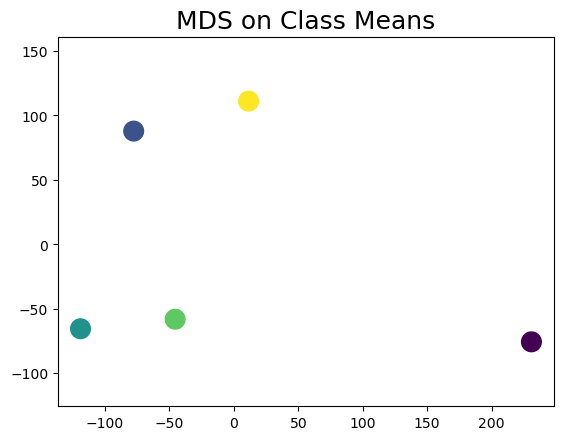

In [17]:
# clutering for k means
Log_X=Log_X.to_numpy()
means = np.array([np.mean(Log_X[np.where(y == i)],axis=0) for i in range(5)])
mds_means = MDS(2,verbose=1,eps=1e-8,n_init=10)
mds_means.fit(means)
plt.scatter(mds_means.embedding_[:,0],mds_means.embedding_[:,1],c=[0,1,2,3,4],s=200)
plt.title("MDS on Class Means",size=18)
plt.axis("equal")
plt.show()


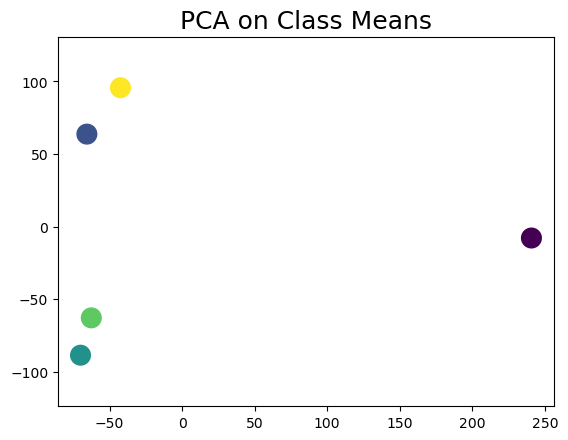

In [18]:
means = np.array([np.mean(Log_X[np.where(y == i)],axis=0) for i in range(5)])
pca_mean=pca.fit_transform(means)
plt.scatter(pca_mean[:,0],pca_mean[:,1],c=[0,1,2,3,4],s=200)

plt.title("PCA on Class Means",size=18)
plt.axis("equal")
plt.show()

[t-SNE] Computing 4 nearest neighbors...
[t-SNE] Indexed 5 samples in 0.000s...
[t-SNE] Computed neighbors for 5 samples in 0.182s...
[t-SNE] Computed conditional probabilities for sample 5 / 5
[t-SNE] Mean sigma: 1869.559663
[t-SNE] KL divergence after 250 iterations with early exaggeration: 36.358212
[t-SNE] KL divergence after 1000 iterations: 0.110969


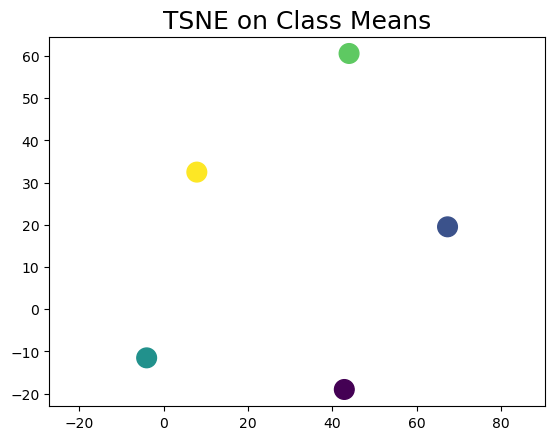

In [19]:
# t-sne on class means
means = np.array([np.mean(Log_X[np.where(y == i)],axis=0) for i in range(5)])
tsne = TSNE(n_components=2,verbose=1,perplexity=4)
tsne_mean=tsne.fit_transform(means)
plt.scatter(tsne_mean[:,0],tsne_mean[:,1],c=[0,1,2,3,4],s=200)

plt.title("TSNE on Class Means",size=18)
plt.axis("equal")
plt.show()


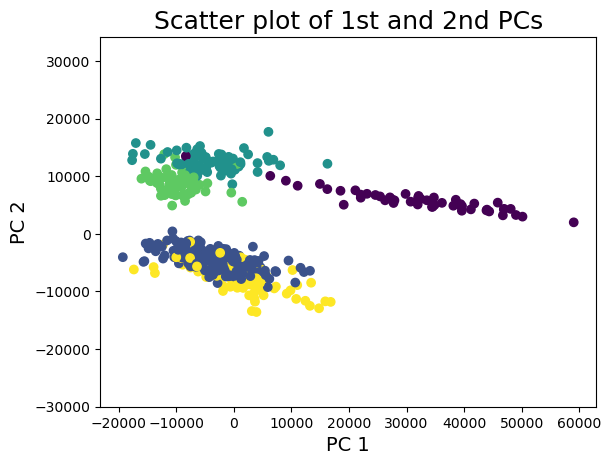

In [20]:
# Perform the PCA, MDS, and T-SNE visualizations on data without log transform

pca = PCA() # Initialize with n_components parameter to only find the top eigenvectors
z = pca.fit_transform(X)


plt.scatter(z[:,0],z[:,1], c=y)
plt.title("Scatter plot of 1st and 2nd PCs",size=18)
plt.xlabel("PC 1",size=14)
plt.ylabel("PC 2",size=14)
plt.axis("equal")
plt.show()

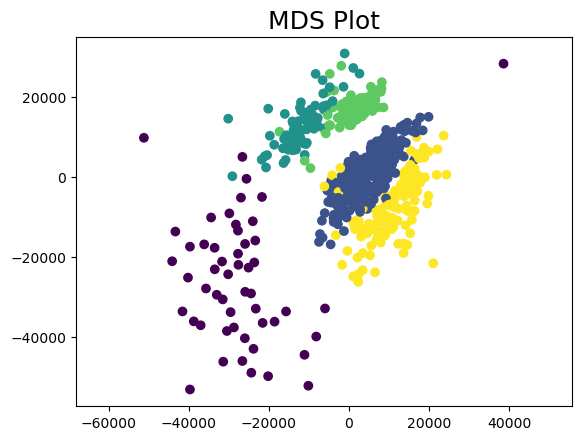

In [23]:
mds = MDS(n_components=2,verbose=1,eps=1e-5)
mds.fit(X)
plt.scatter(mds.embedding_[:,0],mds.embedding_[:,1],c=y)
plt.title("MDS Plot",size=18)
plt.axis("equal")
plt.show()

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 511 samples in 0.056s...
[t-SNE] Computed neighbors for 511 samples in 0.885s...
[t-SNE] Computed conditional probabilities for sample 511 / 511
[t-SNE] Mean sigma: 4717.658619
[t-SNE] KL divergence after 250 iterations with early exaggeration: 50.631351
[t-SNE] KL divergence after 1000 iterations: 0.389077


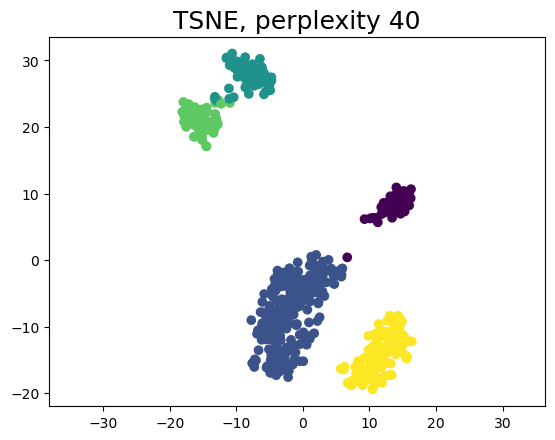

In [24]:
tsne = TSNE(n_components=2,verbose=1,perplexity=40)
z_tsne = tsne.fit_transform(X)
plt.scatter(z_tsne[:,0],z_tsne[:,1], c=y)
plt.title("TSNE, perplexity 40",size=18)
plt.axis("equal")
plt.show()

In [167]:
# Now we will work with the larger, unlabeled subset in p2_unsupervised. This dataset is has not been processed,
#so you should process using the same log transform

X = np.load(r"C:\Users\Vikihyaat Ahlawat\release_gene_analysis_data\data\p2_unsupervised\X.npy")

X=pd.DataFrame(X)
print(X.head())
print(X.shape)
X[0].max()

   0      1           2           3      4          5          6      7      \
0    0.0    0.0  100.392193  117.439923    0.0  45.460615   0.000000    0.0   
1    0.0    0.0   90.884191   68.059394    0.0   0.000000   2.074982    0.0   
2    0.0    0.0   90.391905  102.255843    0.0   0.000000   7.344342    0.0   
3    0.0    0.0   27.619588  149.041548    0.0   0.000000   3.647870    0.0   
4    0.0    0.0  161.172362   77.038362    0.0  51.189964  40.546506    0.0   

        8           9      ...  45758  45759  45760  45761  45762  45763  \
0    0.000000  161.006346  ...    0.0    0.0    0.0    0.0    0.0    0.0   
1  105.409062   10.374908  ...    0.0    0.0    0.0    0.0    0.0    0.0   
2  123.723921   22.033027  ...    0.0    0.0    0.0    0.0    0.0    0.0   
3  211.055339   46.901186  ...    0.0    0.0    0.0    0.0    0.0    0.0   
4  146.981085  177.897795  ...    0.0    0.0    0.0    0.0    0.0    0.0   

   45764  45765  45766  45767  
0    0.0    0.0    0.0    0.0  
1   

61.77721743231262

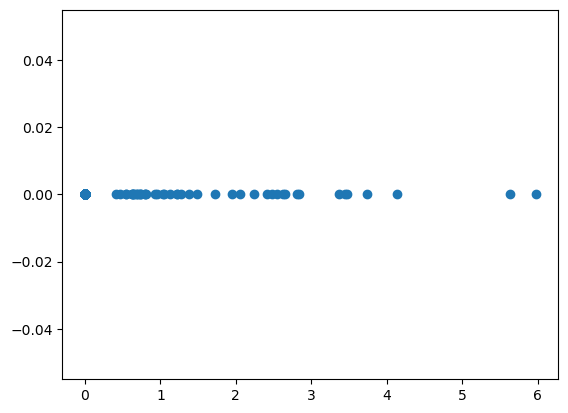

In [168]:
# Due to the presence of genes with extremely high magnitudes of expression in only a few cells, 
#it is common to apply a log-transform to the data, that is, to apply the transform

Log_X= np.log2(X+1)
plt.scatter(Log_X.loc[:,0],Log_X.loc[:,1])
plt.show()

In [169]:
print(Log_X.iloc[:,0].max())
Log_X.head()

5.972169178513185


,0,1,2,3,4,5,6,7,8,9,...,45758,45759,45760,45761,45762,45763,45764,45765,45766,45767
0,0.0,0.0,6.663803,6.888012,0.0,5.537936,0.000000,0.0,0.000000,7.339907,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,6.521745,6.109766,0.0,0.000000,1.620578,0.0,6.733477,3.507783,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,6.513994,6.690080,0.0,0.000000,3.060798,0.0,6.962594,4.525632,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,4.838931,7.229218,0.0,0.000000,2.216570,0.0,7.728297,5.581989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,7.341384,6.286112,0.0,5.705700,5.376655,0.0,7.209269,7.482992,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


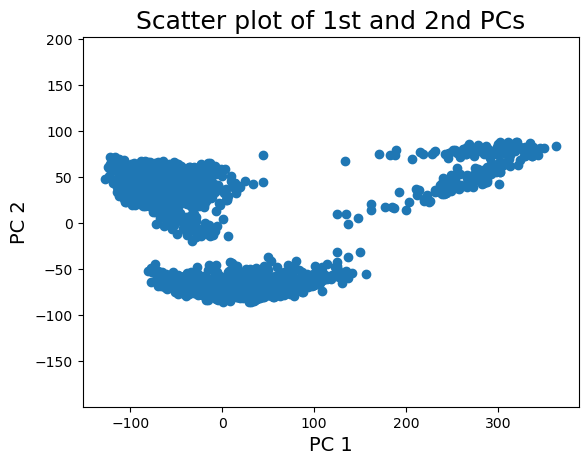

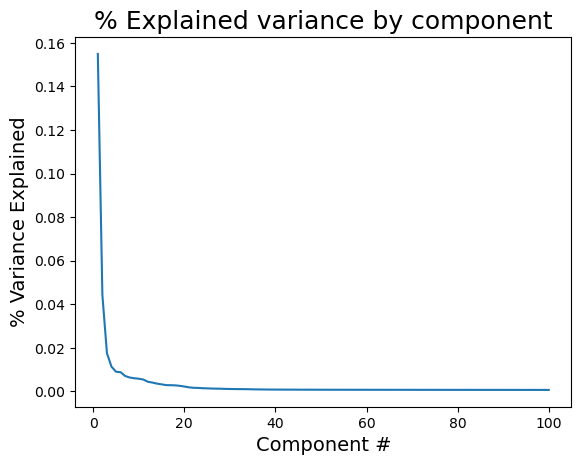

0.5175657790779921

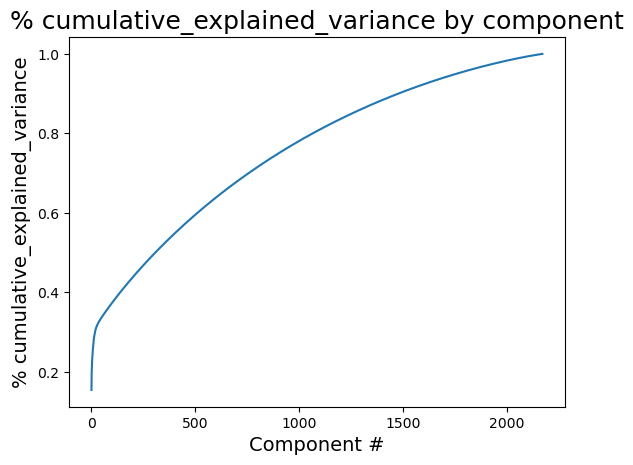

In [189]:
Log_z = pca.fit_transform(Log_X)


plt.scatter(Log_z[:,0],Log_z[:,1])
plt.title("Scatter plot of 1st and 2nd PCs",size=18)
plt.xlabel("PC 1",size=14)
plt.ylabel("PC 2",size=14)
plt.axis("equal")
plt.show()





#Deciding how many principal components to use

# scree/elbow

plt.plot(np.arange(1,101),pca.explained_variance_ratio_[0:100])
plt.title("% Explained variance by component",size=18)
plt.xlabel("Component #",size=14)
plt.ylabel("% Variance Explained",size=14)
plt.show()
#To get a better idea of how the explained variance grow as more PCs are included, plot the cumulative explained variance versus number of PCs.

cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(np.arange(1,len(cumulative_explained_variance) + 1),cumulative_explained_variance)
plt.title("% cumulative_explained_variance by component",size=18)
plt.xlabel("Component #",size=14)
plt.ylabel("% cumulative_explained_variance",size=14)
np.sum(pca.explained_variance_ratio_[0:340])

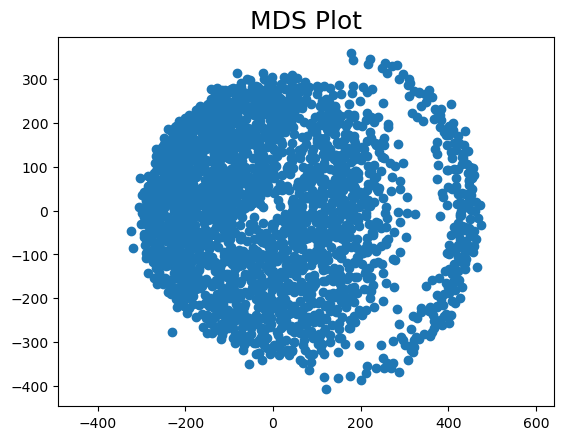

In [174]:
mds = MDS(n_components=2,verbose=1,eps=1e-5)
mds.fit(Log_X)
plt.scatter(mds.embedding_[:,0],mds.embedding_[:,1])
plt.title("MDS Plot",size=18)
plt.axis("equal")
plt.show()

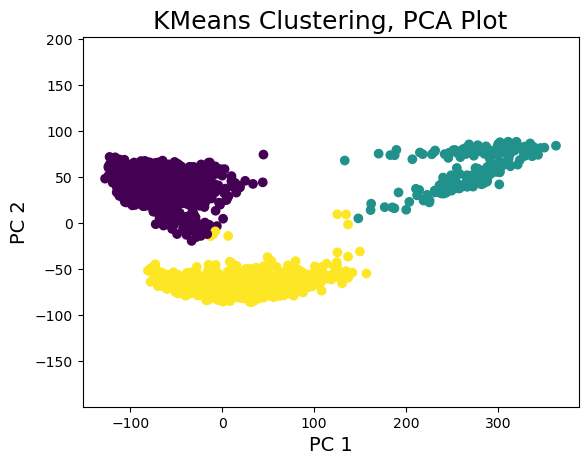

In [205]:
# k mean clustering

kmeans = KMeans(n_clusters=3,n_init=100)
y = kmeans.fit_predict(Log_z)
plt.scatter(Log_z[:,0],Log_z[:,1],c=y)
plt.title("KMeans Clustering, PCA Plot",size=18)
plt.xlabel("PC 1",size=14)
plt.ylabel("PC 2",size=14)
plt.axis("equal")
plt.show()

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2169 samples in 0.044s...
[t-SNE] Computed neighbors for 2169 samples in 0.574s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2169
[t-SNE] Computed conditional probabilities for sample 2000 / 2169
[t-SNE] Computed conditional probabilities for sample 2169 / 2169
[t-SNE] Mean sigma: 44.090936
[t-SNE] KL divergence after 250 iterations with early exaggeration: 67.094925
[t-SNE] KL divergence after 1000 iterations: 1.534141


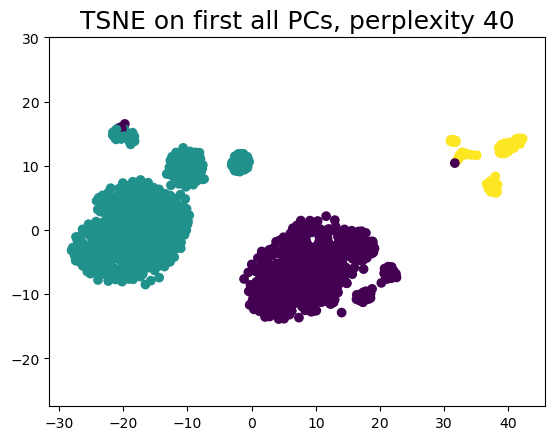

In [176]:
# tsne on first n PCs

tsne = TSNE(n_components=2,verbose=1,perplexity=40)
z_tsne = tsne.fit_transform(Log_z)
plt.scatter(z_tsne[:,0],z_tsne[:,1], c=y)
plt.title("TSNE on first all PCs, perplexity 40",size=18)
plt.axis("equal")
plt.show()

#tsne2 = TSNE(n_components=2,verbose=1,perplexity=40)
#z_tsne2 = tsne2.fit_transform(Log_X)

#fig,(ax1,ax2) = plt.subplots(1, 2,figsize=(10,4))
#ax1.scatter(z_tsne[:,0],z_tsne[:,1])
#ax1.set_title("Dataset 1, TSNE",size=18)
#ax1.axis("equal")

#ax2.scatter(z_tsne2[:,0],z_tsne2[:,1])
#ax2.set_title("Dataset 2, TSNE",size=18)
#ax2.axis("equal")
#plt.show()

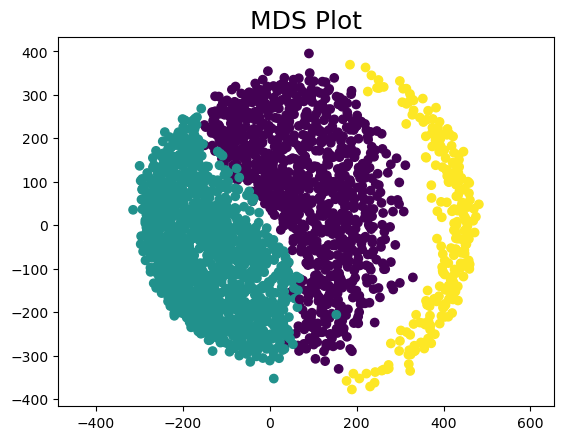

In [32]:
plt.scatter(mds.embedding_[:,0],mds.embedding_[:,1],c=y)
plt.title("MDS Plot",size=18)
plt.axis("equal")
plt.show()

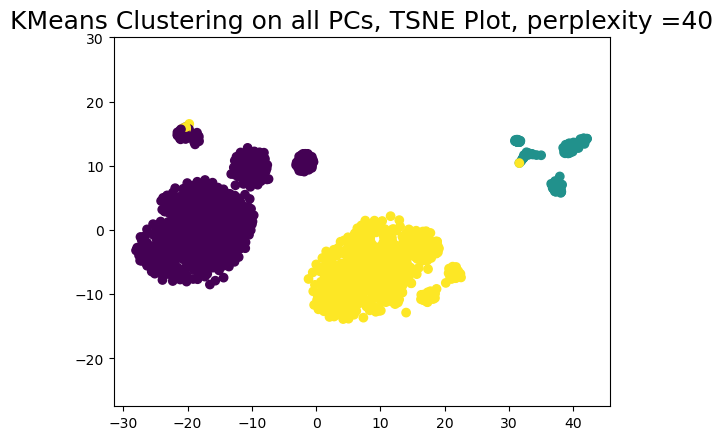

In [206]:
plt.scatter(z_tsne[:,0],z_tsne[:,1],c=y)
plt.title("KMeans Clustering on all PCs, TSNE Plot, perplexity =40",size=18)
plt.axis("equal")
plt.show()

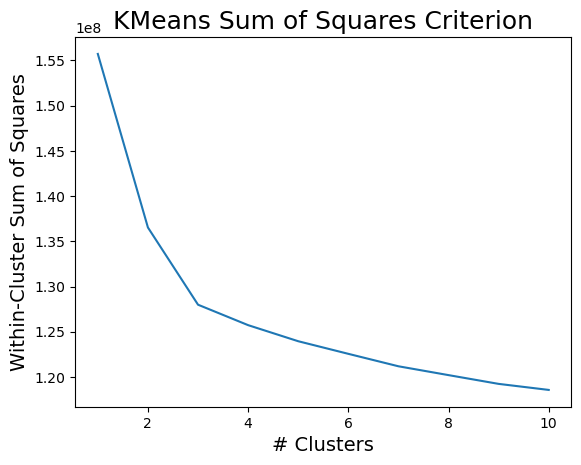

In [34]:
all_kmeans = [KMeans(n_clusters=i+1,n_init=100) for i in range(10)]
# i-th kmeans fits i+1 clusters
for i in range(10):
    all_kmeans[i].fit(Log_z)

inertias = [all_kmeans[i].inertia_ for i in range(10)]
plt.plot(np.arange(1,11),inertias)
plt.title("KMeans Sum of Squares Criterion",size=18)
plt.xlabel("# Clusters",size=14)
plt.ylabel("Within-Cluster Sum of Squares",size=14)
plt.savefig("elbow.png")
plt.show()

In [35]:
from sklearn.metrics import silhouette_score, silhouette_samples


In [36]:
%pip install yellowbrick

from yellowbrick.cluster import SilhouetteVisualizer
from yellowbrick.style import rcmod
from yellowbrick.style.colors import resolve_colors

# Ignore the warning that will pop up when we do rcmod.reset_orig()
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='matplotlib')
# Yellowbrick changes the plotting settings, reset to default here

rcmod.reset_orig()

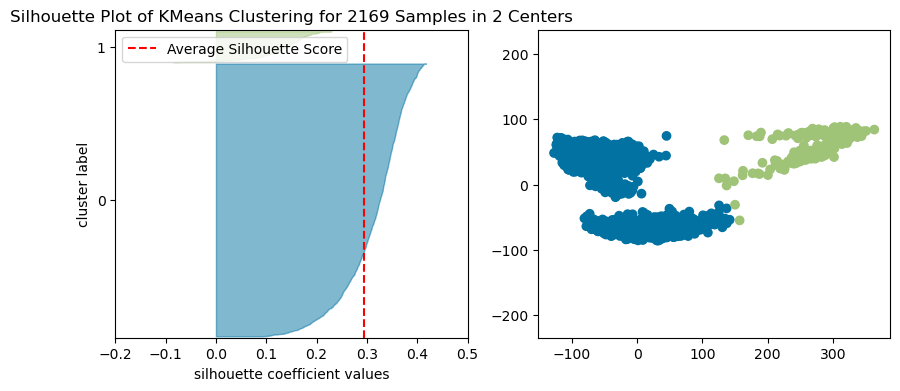

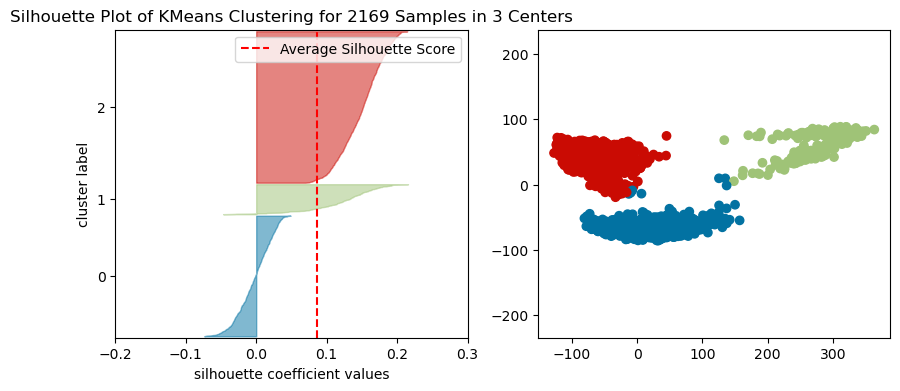

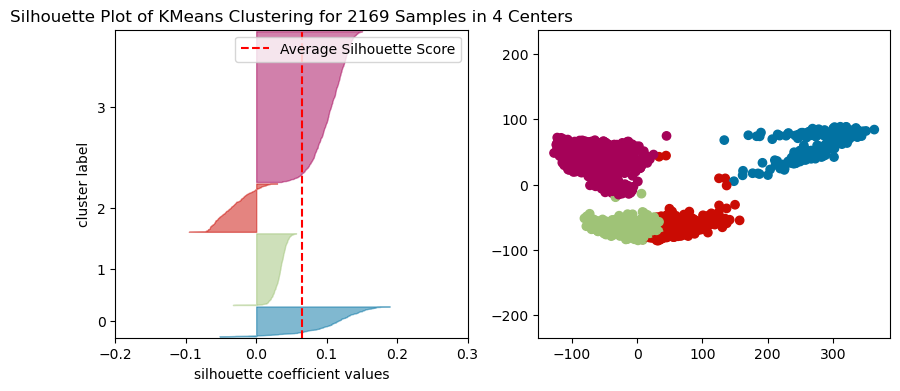

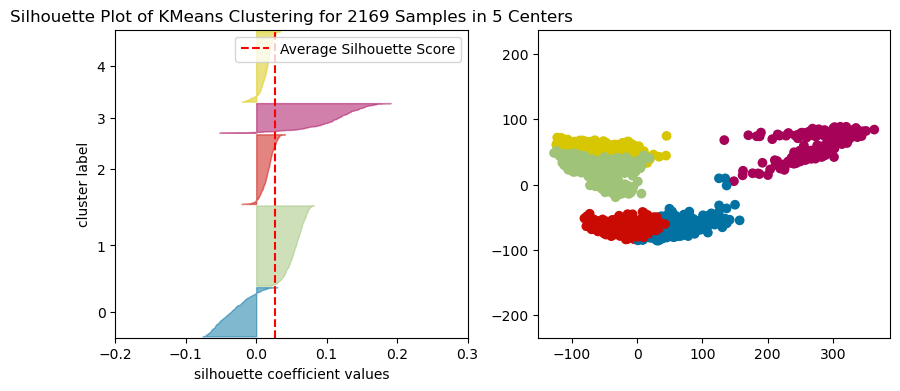

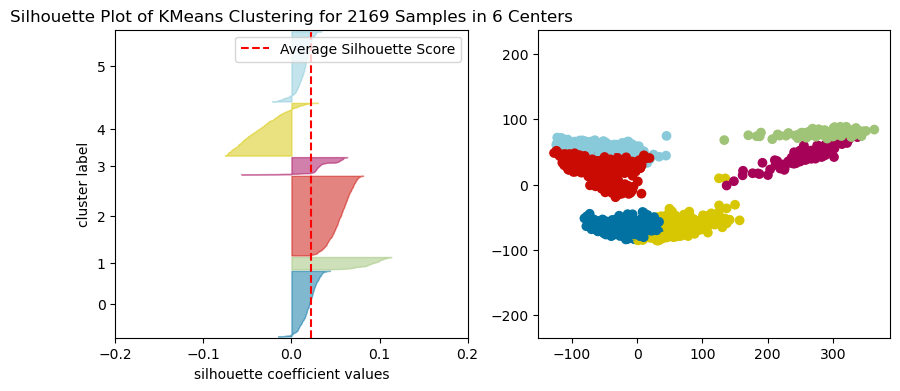

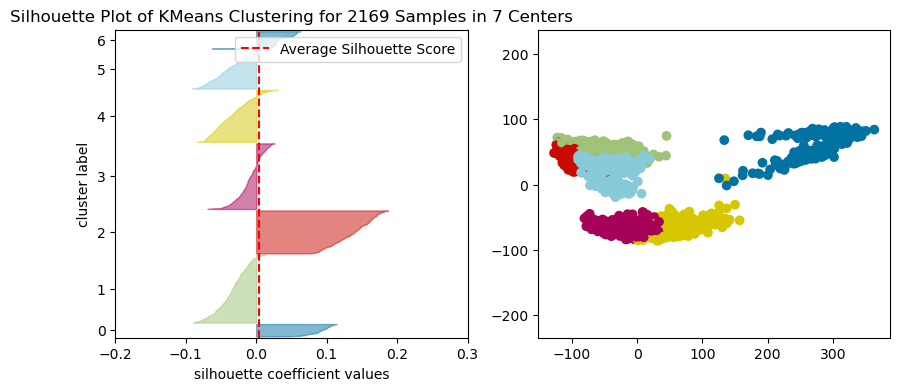

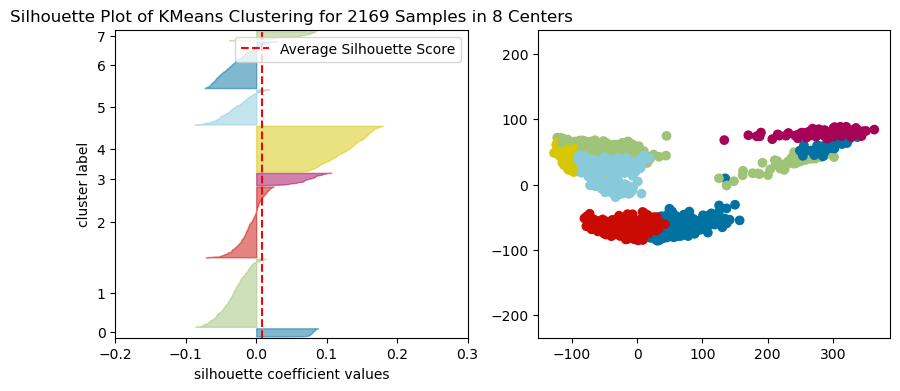

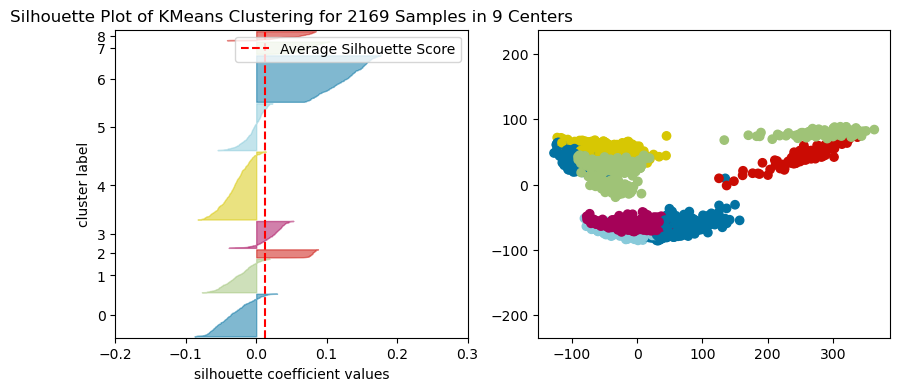

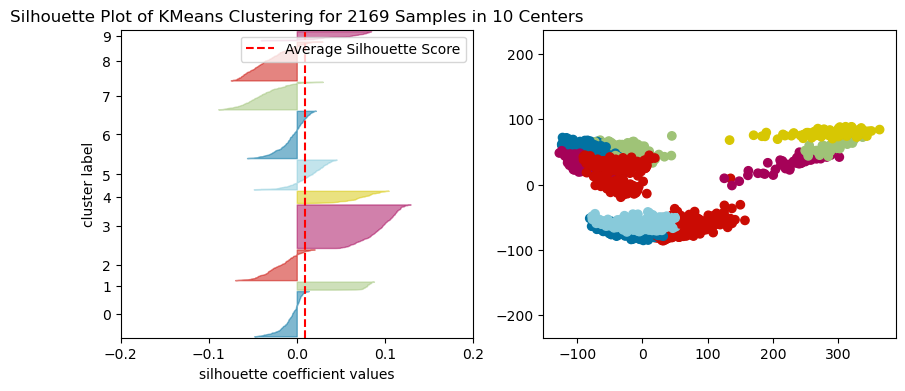

In [37]:
visualizers = [SilhouetteVisualizer(all_kmeans[i], colors='yellowbrick',is_fitted=True) for i in range(1,10)]
for i in range(9):
    fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(10,4))
    visualizer = SilhouetteVisualizer(all_kmeans[i+1], colors='yellowbrick',is_fitted=True,ax=ax1)
    visualizer.fit(Log_z)
    
    colors = np.array(resolve_colors(i+2,"yellowbrick"))
    ax2.scatter(Log_z[:,0],Log_z[:,1],c=colors[all_kmeans[i+1].labels_])
    ax2.axis("equal")
    
    # If we want to set axes to be the same for all plots, need to do something like this
    # instead of visualizer.show(), which resets the axes
    visualizer.show()
    #visualizer.finalize()
    ax1.set_xlim((-.4,.8))
    filename = f'Silhouttepca_{i}.png'
    fig.savefig(filename, dpi=200)

    # Close the figure to free up memory
    plt.close(fig)
    
    plt.show()
   

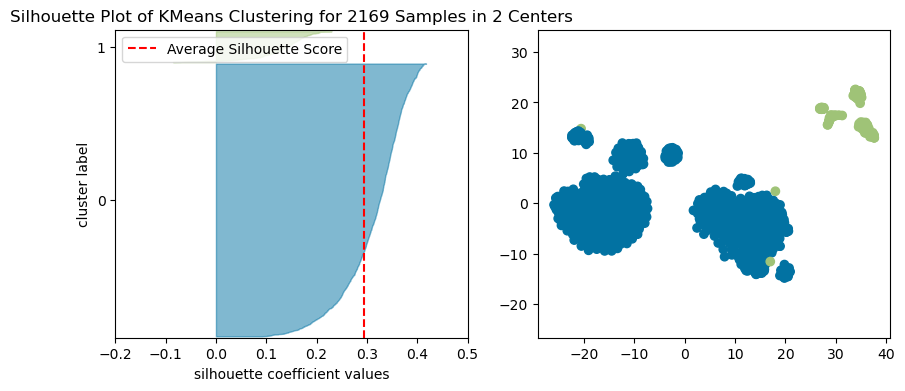

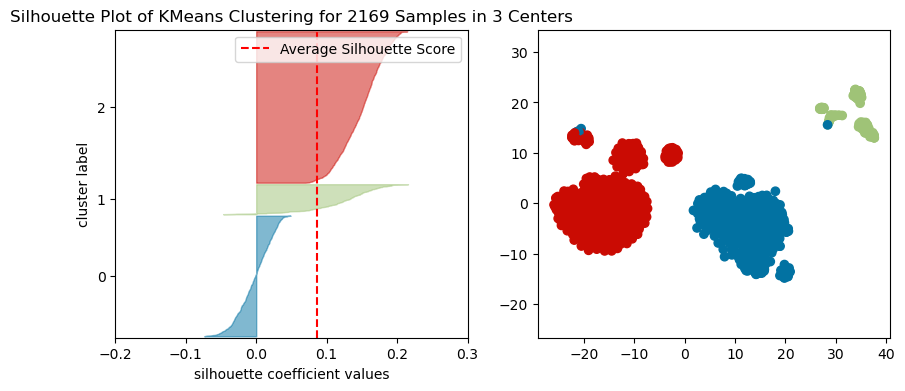

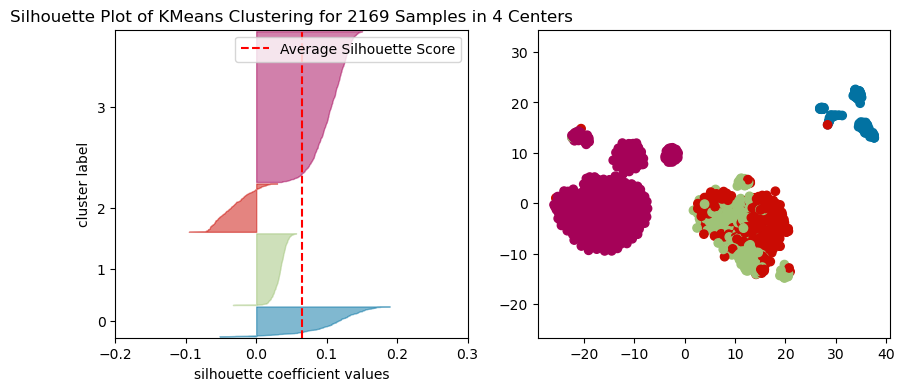

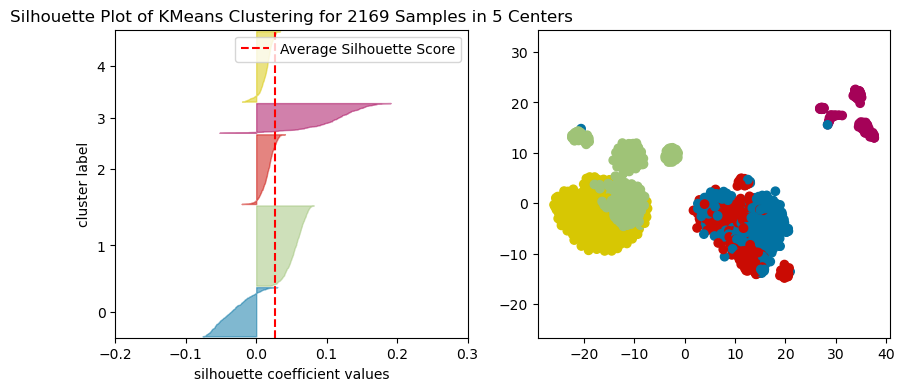

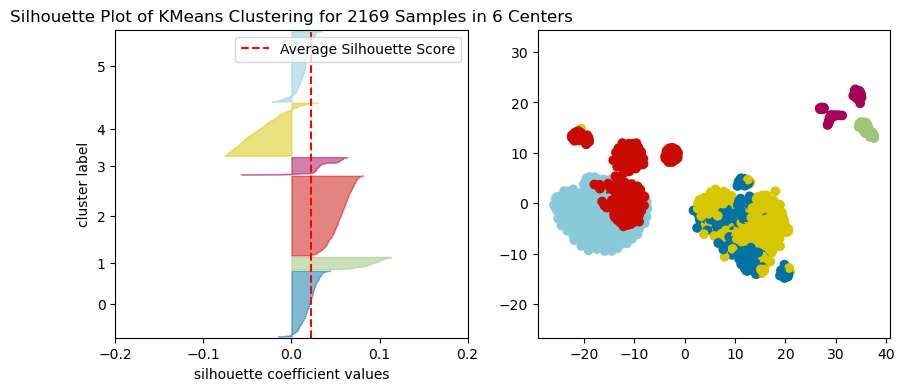

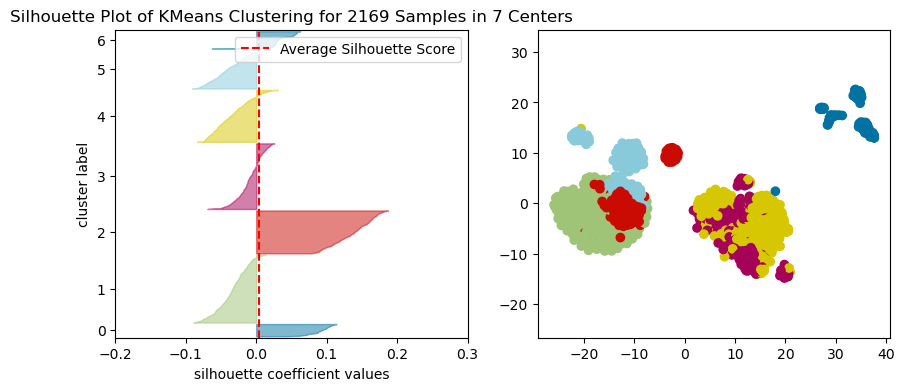

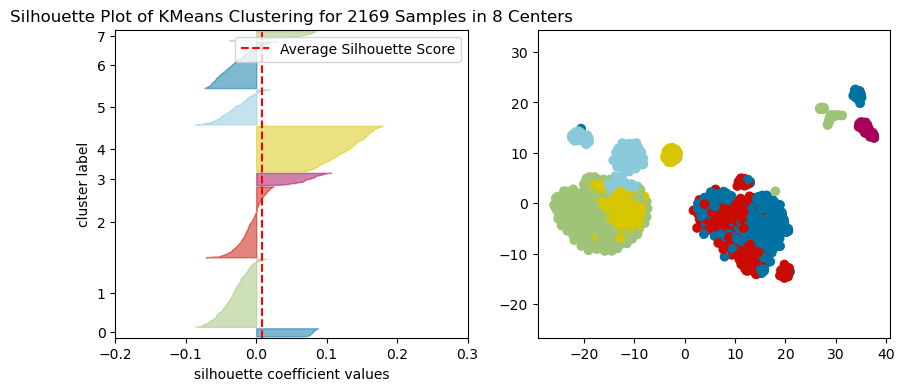

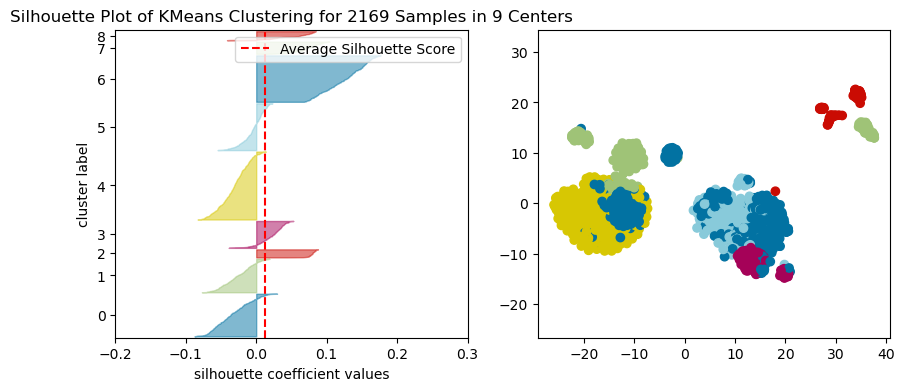

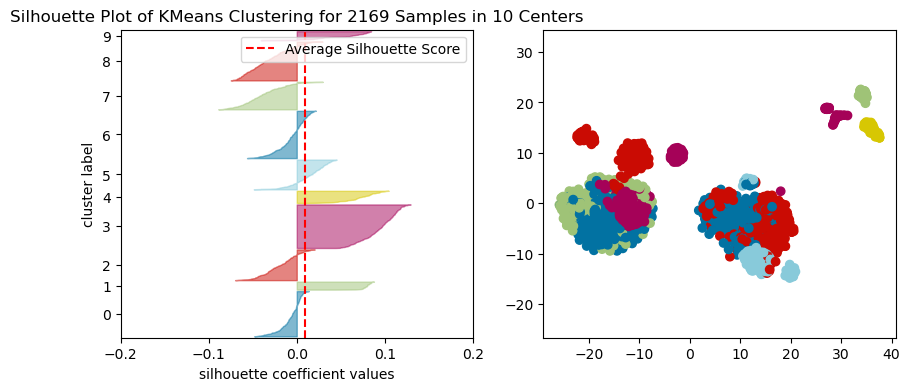

In [38]:
visualizers = [SilhouetteVisualizer(all_kmeans[i], colors='yellowbrick',is_fitted=True) for i in range(1,10)]
for i in range(9):
    fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(10,4))
    visualizer = SilhouetteVisualizer(all_kmeans[i+1], colors='yellowbrick',is_fitted=True,ax=ax1)
    visualizer.fit(Log_z)
    
    colors = np.array(resolve_colors(i+2,"yellowbrick"))
    ax2.scatter(z_tsne[:,0],z_tsne[:,1],c=colors[all_kmeans[i+1].labels_])
    ax2.axis("equal")
    
    # If we want to set axes to be the same for all plots, need to do something like this
    # instead of visualizer.show(), which resets the axes
    visualizer.show()
    #visualizer.finalize()
    ax1.set_xlim((-.4,.8))
    filename = f'Silhoutte_{i}.png'
    fig.savefig(filename, dpi=200)

    # Close the figure to free up memory
    plt.close(fig)
    
    plt.show()
   

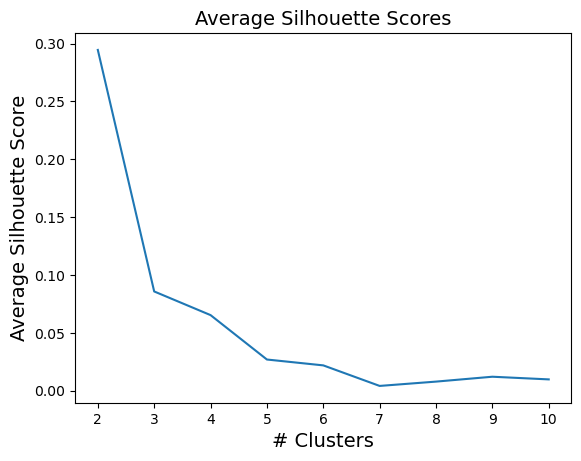

In [39]:
plt.savefig("Silhouette plot of kmean clustering with 2169 samples.png")
# Silhouette score undefined for 1 class. i-th entry of avg_silhouette score is score for i+2 clusters.
avg_silhouette_scores = [silhouette_score(Log_z,all_kmeans[i].labels_) for i in range(1,10)]
plt.plot(np.arange(2,11),avg_silhouette_scores)
plt.title("Average Silhouette Scores",size=14)
plt.xlabel("# Clusters",size=14)
plt.ylabel("Average Silhouette Score",size=14)
plt.show()

In [40]:
# Now we will work with the larger, unlabeled subset in p2_unsupervised. This dataset is has not been processed,
#so you should process using the same log transform

X = np.load(r"C:\Users\Vikihyaat Ahlawat\release_gene_analysis_data\data\p2_unsupervised\X.npy")

X=pd.DataFrame(X)

Log_X= np.log2(X+1)

In [43]:
# k means clustering

from sklearn.cluster import KMeans

In [44]:
# we selecct six clusters to subgroup three major cell categories
clustering = KMeans(6,n_init=10)
clustering.fit(Log_X)
colors = np.array(resolve_colors(6,"yellowbrick"))
clustering.labels_.shape

(2169,)

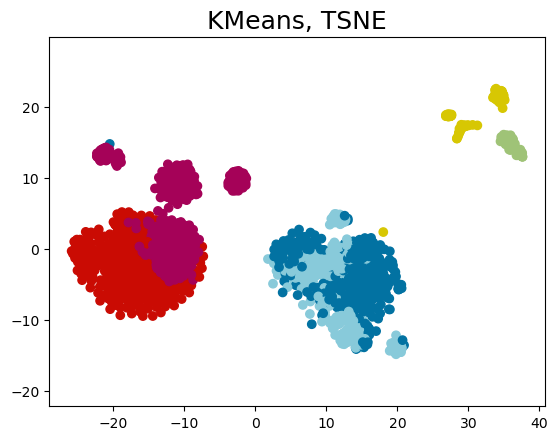

In [45]:
plt.scatter(z_tsne[:,0],z_tsne[:,1],c=colors[clustering.labels_])
plt.title("KMeans, TSNE",size=18)
plt.axis("equal")
plt.show()

In [46]:
# Logistic regression

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score

In [233]:
np.random.seed(317)
Log_X=Log_X.to_numpy()
perm = np.random.permutation(Log_X.shape[0])
n_train = int(4/5*Log_X.shape[0])
print(n_train)
X_train = Log_X[perm[:n_train]]
X_test = Log_X[perm[n_train:]]
y_train = clustering.labels_[perm[:n_train]]
y_test = clustering.labels_[perm[n_train:]]
y_train.shape
X_train.shape

1735


(1735, 45768)

In [234]:
# one-versus-rest approach to multiclass logistic regression

log_reg = LogisticRegression(penalty=None,multi_class="ovr").fit(X_train,y_train) # one over rest


In [235]:
log_reg.score(X_train,y_train)

1.0

In [236]:
log_reg.score(X_test,y_test)

0.9907834101382489

In [237]:
# C is inverse regularization strength. Small C -> more regularization.

#Logistic regression is solved via iterative methods: different solvers exist, some support certain types of regularization or multi-class objective. 
#Check documentation!

## Some solvers only support certain regularization/multi_class parameters
log_reg = LogisticRegression(penalty="l1",C=0.1,solver="liblinear",max_iter=5000,multi_class="ovr").fit(X_train,y_train)
log_reg.score(X_train,y_train)


0.9994236311239193

In [238]:
log_reg.score(X_test,y_test)

0.9746543778801844

In [239]:
# Cross validation
log_reg = LogisticRegressionCV(cv=5,Cs=[0.01,0.1,1,10],max_iter=5000,penalty="l1",solver="liblinear",multi_class="ovr")
log_reg.fit(X_train,y_train)
log_reg.score(X_train,y_train)


0.9994236311239193

In [240]:
log_reg.score(X_test,y_test)

0.9723502304147466

In [241]:
log_reg.C_

array([ 0.01,  1.  , 10.  ,  0.1 , 10.  ,  0.01])

In [242]:
log_reg.scores_

{0: array([[0.99711816, 1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        , 1.        ],
        [0.99711816, 0.99423631, 0.99423631, 0.99423631],
        [0.99711816, 0.99711816, 0.99711816, 0.99711816],
        [1.        , 1.        , 1.        , 1.        ]]),
 1: array([[1.        , 1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        , 1.        ],
        [0.99711816, 1.        , 1.        , 1.        ],
        [0.99135447, 1.        , 1.        , 1.        ],
        [0.98847262, 0.99423631, 0.99711816, 0.99711816]]),
 2: array([[0.93948127, 0.96253602, 0.95677233, 0.95965418],
        [0.95965418, 0.98847262, 0.98559078, 0.98847262],
        [0.93659942, 0.96829971, 0.9740634 , 0.97694524],
        [0.9481268 , 0.9740634 , 0.9740634 , 0.97118156],
        [0.95677233, 0.96829971, 0.97118156, 0.98847262]]),
 3: array([[0.99711816, 0.99711816, 0.99711816, 0.99711816],
        [1.        , 1.        , 0.99711816, 0.9971181

In [251]:
# selecting features
log_reg.coef_

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.00097231, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [252]:
#One way: look at sum of absolute value per column
np.sum(np.abs(log_reg.coef_),axis=0)



array([0.        , 0.        , 0.00097231, ..., 0.        , 0.        ,
       0.        ])

In [253]:
# picking features with 100 largest coefficent/ features

n_largest = 100

# Get the indices that would sort the array in ascending order
sorted_indices = np.argsort(np.sum(np.abs(log_reg.coef_),axis=0))

# The last n_largest elements of sorted_indices correspond to the largest values
# Slicing with [::-1] reverses the array to get descending order of values
# Then take the first n_largest elements for the indices of the largest values
indices_of_largest = sorted_indices[::-1][:n_largest]

print(indices_of_largest)
log_reg = LogisticRegressionCV(cv=5,Cs=[0.001,0.01,0.1,1,10],max_iter=5000,penalty="l1",solver="liblinear",multi_class="ovr")
log_reg.fit(X_train[:,indices_of_largest],y_train)

[ 4356  8196 36985  8722  8098  6487 45017  4197 38971 32262 40650  4851
 41899 36571 37704 31432  5688 35059 31647 34077 31936 45203 41151 31893
   662 24422 24335 43065 37616  5597 34572 32261 23648 40737  5867 43511
  3977 23678 40470  7412 38255  6756 25444 32041  8001 25006 40741  3483
  5512 40633 36780  6726  7768 36671  4855 25434    66 31892  7439  8586
 45691 36955 23974 43613 39722  5341  6482 25185  3579 39443 42365 43509
  5586 23677 25183  9356 39732 24339 31941  8325 31977 39558 40433 43478
  7469 39051 43283  4441 33783 37252 40759 36788 24567 32109 35128  5390
 36986 31568 38836 40160]


LogisticRegressionCV(Cs=[0.001, 0.01, 0.1, 1, 10], cv=5, max_iter=5000,
                     multi_class='ovr', penalty='l1', solver='liblinear')

In [265]:
log_reg.score(X_train[:,indices_of_largest],y_train)


0.9994236311239193

In [267]:
log_reg.score(X_test[:,indices_of_largest],y_test)

0.9654377880184332

In [269]:
#Comparing two different datasets
# Now we will work with  p2_uevaluation and compare to p2_unsupervised.
#This dataset is has not been processed,
#so you should process using the same log transform

X_train_eval = np.load(r"C:\Users\Vikihyaat Ahlawat\release_gene_analysis_data\data\p2_evaluation\X_train.npy")
X_test_eval=np.load(r"C:\Users\Vikihyaat Ahlawat\release_gene_analysis_data\data\p2_evaluation\X_test.npy")
y_train_eval=np.load(r"C:\Users\Vikihyaat Ahlawat\release_gene_analysis_data\data\p2_evaluation\y_train.npy")
y_test_eval=np.load(r"C:\Users\Vikihyaat Ahlawat\release_gene_analysis_data\data\p2_evaluation\y_test.npy")

X_train_eval=pd.DataFrame(X_train_eval)
X_test_eval=pd.DataFrame(X_test_eval)
y_train_eval=pd.DataFrame(y_train_eval)
y_test_eval=pd.DataFrame(y_test_eval)
print(X_train_eval.head())
print(y_train_eval.shape)

# Apply log transform (log2(x+1))
X_train_log = np.log2(X_train_eval + 1)
X_test_log = np.log2(X_test_eval + 1)


   0      1           2           3      4          5          6      7      \
0    0.0    0.0    0.000000  147.363076    0.0   1.459040   2.188561    0.0   
1    0.0    0.0  141.785276   90.460289    0.0  26.304056   0.000000    0.0   
2    0.0    0.0  110.805337  128.970146    0.0  22.706012   5.449443    0.0   
3    0.0    0.0   92.217817  101.703079    0.0   0.000000   2.634795    0.0   
4    0.0    0.0    0.000000  362.763720    0.0  44.111015  16.459334    0.0   

       8          9      ...  45758  45759  45760  45761  45762  45763  45764  \
0  84.624341  19.697045  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
1  60.306859   9.623435  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
2   0.000000  65.393314  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
3  30.036661  86.948228  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
4   6.583734  40.819148  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0   

   45765  45766  45767  
0    0.0    0

In [279]:
# Train and evaluate with selected coefficient features
X_train_coef_selected = X_train_log[indices_of_largest]
X_test_coef_selected = X_test_log[indices_of_largest]
log_reg = LogisticRegressionCV(cv=5,Cs=[0.01,0.1,1,10],max_iter=5000,penalty="l1",solver="liblinear",multi_class="ovr")
log_reg.fit(X_train_coef_selected,y_train_eval)
print(log_reg.score(X_test_coef_selected,y_test_eval))
print(f"Score with coefficient-selected features: {log_reg.score(X_test_coef_selected,y_test_eval)}")


D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.8474729241877257
Score with coefficient-selected features: 0.8474729241877257


In [273]:
# 2. Baseline: Random features
np.random.seed(42) # for reproducibility
random_features = np.random.choice(X_train_log.columns, 100, replace=False)
X_train_random = X_train_log[random_features]
X_test_random = X_test_log[random_features]
log_reg_random = LogisticRegressionCV(cv=5,Cs=[0.01,0.1,1,10],max_iter=5000,penalty="l1",solver="liblinear",multi_class="ovr")
log_reg_random.fit(X_train_random, y_train_eval)
score_random = log_reg_random.score(X_test_random, y_test_eval)
print(f"Score with 100 random features: {score_random:.4f}")


D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Score with 100 random features: 0.3439


In [275]:
# 3. Baseline: High-variance features
feature_variances = X_train_log.var()
top_100_variance_indices = np.argsort(feature_variances)[-100:]
high_variance_features = X_train_log.columns[top_100_variance_indices]
X_train_variance = X_train_log[high_variance_features]
X_test_variance = X_test_log[high_variance_features]
log_reg_variance = LogisticRegressionCV(cv=5,Cs=[0.01,0.1,1,10],max_iter=5000,penalty="l1",solver="liblinear",multi_class="ovr")
log_reg_variance.fit(X_train_variance, y_train_eval)
score_variance = log_reg_variance.score(X_test_variance, y_test_eval)
print(f"Score with top 100 high-variance features: {score_variance:.4f}")

D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Score with top 100 high-variance features: 0.9143


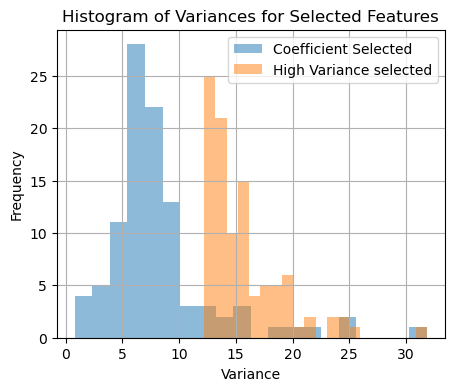

In [277]:
# 4. Compare variances
variances_coef_selected = X_train_log[indices_of_largest].var()
variances_high_variance_selected = X_train_log[high_variance_features].var()

plt.figure(figsize=(5, 4))
plt.hist(variances_coef_selected, bins=20, alpha=0.5, label='Coefficient Selected')
plt.hist(variances_high_variance_selected, bins=20, alpha=0.5, label='High Variance selected')
plt.title('Histogram of Variances for Selected Features')
plt.xlabel('Variance')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()